In [ ]:
# Loan-Level Data

select
b.BLOCK_TIMESTAMP,
b.TX_HASH,
b.EVENT_NAME,
b.ORIGIN_FROM_ADDRESS,
b.ORIGIN_TO_ADDRESS,
b.PLATFORM,
b.BORROWER,
b.TOKEN_ADDRESS,
b.TOKEN_SYMBOL,
m.SYMBOL,
m.NAME,
m.DECIMALS,
b.AMOUNT_UNADJ,
b.AMOUNT,
b.AMOUNT_USD
from base.defi.ez_lending_borrows as b
left join base.price.ez_asset_metadata as m
ON b.TOKEN_ADDRESS = m.TOKEN_ADDRESS
where b.BLOCK_TIMESTAMP between ('2024-01-01') and ('2024-03-01')
and PLATFORM = 'Aave V3' ;

In [28]:
# 📊 Data Handling
import pandas as pd
import numpy as np
import requests

# 📈 Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ⚙️ Preprocessing & Scaling
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# 📈 Analysis
import scipy.stats as stats
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
  
# 🧠 Modeling
from sklearn.cluster import KMeans, DBSCAN
import hdbscan
from sklearn.metrics import silhouette_score

## 0: Import data

In [37]:
# brrows
br_df = pd.read_csv('01_borrows_data.csv',on_bad_lines='skip')
# deposits
depo_df = pd.read_csv('deposits.csv',on_bad_lines='skip')
# liquidations
lq_df = pd.read_csv('liquidations.csv',on_bad_lines='skip')
# repayments
py_df = pd.read_csv('repayments.csv',on_bad_lines='skip')

/var/folders/nw/7766myvd65gfypd6nd1lgsb40000gn/T/ipykernel_10526/1366487729.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  depo_df = pd.read_csv('deposits.csv',on_bad_lines='skip')


In [74]:
# brrows data
br_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16395 entries, 0 to 16394
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BLOCK_TIMESTAMP      16395 non-null  object 
 1   TX_HASH              16394 non-null  object 
 2   EVENT_NAME           16394 non-null  object 
 3   ORIGIN_FROM_ADDRESS  16394 non-null  object 
 4   ORIGIN_TO_ADDRESS    16394 non-null  object 
 5   PLATFORM             16394 non-null  object 
 6   BORROWER             16394 non-null  object 
 7   TOKEN_ADDRESS        16394 non-null  object 
 8   TOKEN_SYMBOL         16394 non-null  object 
 9   SYMBOL               16394 non-null  object 
 10  NAME                 16394 non-null  object 
 11  DECIMALS             16394 non-null  float64
 12  AMOUNT_UNADJ         16394 non-null  object 
 13  AMOUNT               16394 non-null  float64
 14  AMOUNT_USD           15948 non-null  float64
dtypes: float64(3), object(12)
memory usa

# 4.2 Brownian Motion

In [76]:
borrow_stats = br_df.groupby("BORROWER")["AMOUNT_USD"].sum().rename("TOTAL_BORROWED")

repay_stats = py_df.groupby("BORROWER")["AMOUNT_USD"].sum().rename("TOTAL_REPAID")

user_profile_df = pd.concat([borrow_stats, repay_stats], axis=1).fillna(0)

user_profile_df["REPAYMENT_RATIO"] = (
    user_profile_df["TOTAL_REPAID"] / user_profile_df["TOTAL_BORROWED"]
).clip(upper=1.0)

liq_counts = lq_df.groupby("BORROWER")["AMOUNT_USD"].count().rename("NUM_LIQUIDATIONS")

liq_total = lq_df.groupby("BORROWER")["AMOUNT_USD"].sum().rename("TOTAL_LIQUIDATED")

user_profile_df = user_profile_df.join([liq_counts, liq_total]).fillna(0)

user_profile_df["HIGH_RISK_FLAG"] = (
    (user_profile_df["REPAYMENT_RATIO"] < 0.5) |
    (user_profile_df["NUM_LIQUIDATIONS"] > 1)
).astype(int)

user_profile_df.head()

,TOTAL_BORROWED,TOTAL_REPAID,REPAYMENT_RATIO,NUM_LIQUIDATIONS,TOTAL_LIQUIDATED,HIGH_RISK_FLAG
BORROWER,,,,,,
0x00000002d88f9b3f4eb303564817fff4adcde46f,68.89,0.00,0.0,0.0,0.0,1
0x0005fbbd3e152468067948c9090c3d0d8c252017,149.25,149.35,1.0,0.0,0.0,0
0x000d708dfbf2568f3d4ff70ba808bfec46fc9c37,12634.08,12638.42,1.0,0.0,0.0,0
0x0011d1bf509615803ad29647139fe9f1ebf5ee42,0.06,0.00,0.0,0.0,0.0,1
0x001b4c33f260fa3c52470259001e4e1c43a7a689,12.00,0.00,0.0,0.0,0.0,1


In [85]:
user_profile_df['NUM_LIQUIDATIONS'].value_counts()

0.0    11077
1.0      183
2.0       31
3.0        9
Name: NUM_LIQUIDATIONS, dtype: int64

In [84]:
# آماره توصیفی کاربران لیکوئید شده در مقابل نشده
user_profile_df.groupby("NUM_LIQUIDATIONS")[["TOTAL_BORROWED", "REPAYMENT_RATIO", "TOTAL_REPAID"]].describe()

TOTAL_BORROWED                                            \
                          count         mean           std    min     25%   
NUM_LIQUIDATIONS                                                            
0.0                     11077.0  2557.054526  50617.459399   0.00   1.400   
1.0                       183.0   575.704481   4735.734231   0.00  22.155   
2.0                        31.0   132.466774     99.596589  10.22  57.380   
3.0                         9.0   149.445556    119.934585   0.00  55.940   

                                              REPAYMENT_RATIO            ...  \
                     50%      75%         max           count      mean  ...   
NUM_LIQUIDATIONS                                                         ...   
0.0                13.01  307.420  3660135.33         11077.0  0.714753  ...   
1.0                46.82  100.615    59584.40           183.0  0.429837  ...   
2.0               126.81  170.815      489.25            31.0  0.592917  ...   
3.0                95.52  249.860      353.62             9.0  0.634490  ...   

                                TOTAL_REPAID                                  \
                       75%  max        count         mean           std  min   
NUM_LIQUIDATIONS                                                               
0.0               1.000000  1.0      11077.0  2190.430119  49329.678499  0.0   
1.0               0.664843  1.0        183.0   266.295137   1886.677683  0.0   
2.0               0.778015  1.0         31.0    84.117419     71.776649  0.0   
3.0               0.764101  1.0          9.0   104.105556     81.482220  0.0   

                                                      
                     25%    50%      75%         max  
NUM_LIQUIDATIONS                                      
0.0                0.000  10.06  284.660  3736749.67  
1.0                0.000  23.31   52.730    21194.87  
2.0               30.095  60.12  131.715      342.68  
3.0               38.160  92.81  187.590      219.05  

[4 rows x 24 columns]

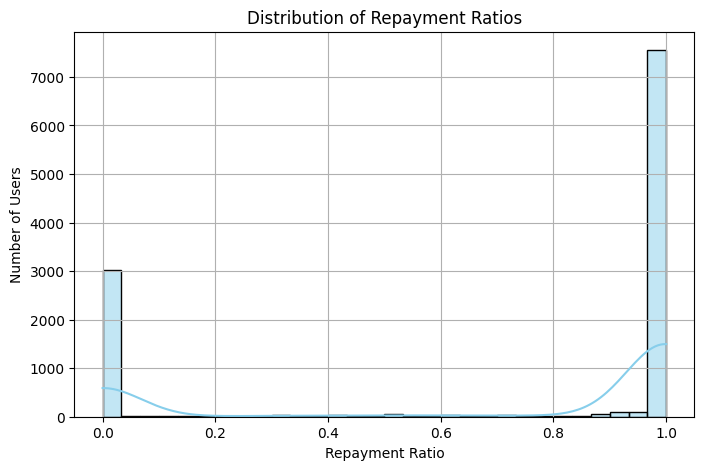

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(user_profile_df["REPAYMENT_RATIO"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Repayment Ratios")
plt.xlabel("Repayment Ratio")
plt.ylabel("Number of Users")
plt.grid(True)
plt.show()

/var/folders/nw/7766myvd65gfypd6nd1lgsb40000gn/T/ipykernel_10526/3376764498.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


ValueError: The palette dictionary is missing keys: {'3.0', '0.0', '1.0', '2.0'}

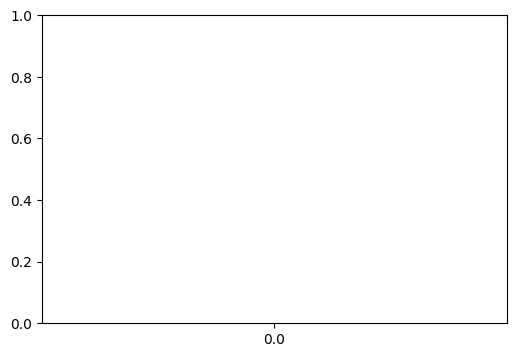

In [83]:
plt.figure(figsize=(8, 5))
sns.countplot(x="NUM_LIQUIDATIONS", data=user_profile_df, color="salmon")
plt.title("Number of Liquidations per User")
plt.xlabel("Liquidation Count")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()



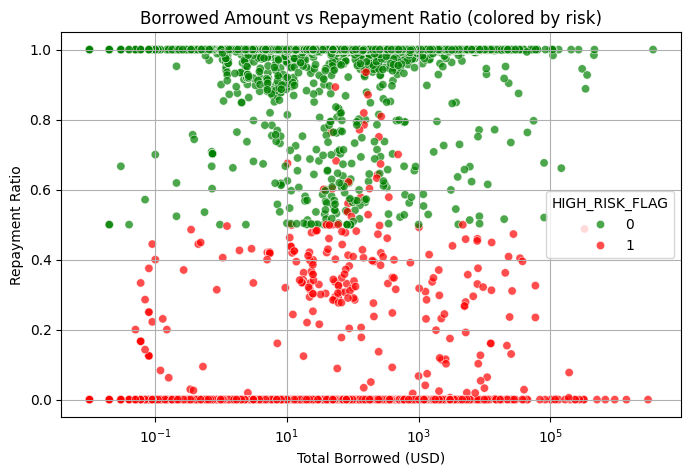

In [81]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="TOTAL_BORROWED",
    y="REPAYMENT_RATIO",
    hue="HIGH_RISK_FLAG",
    data=user_profile_df,
    palette={0: "green", 1: "red"},
    alpha=0.7
)
plt.title("Borrowed Amount vs Repayment Ratio (colored by risk)")
plt.xlabel("Total Borrowed (USD)")
plt.ylabel("Repayment Ratio")
plt.xscale("log")
plt.grid(True)
plt.show()

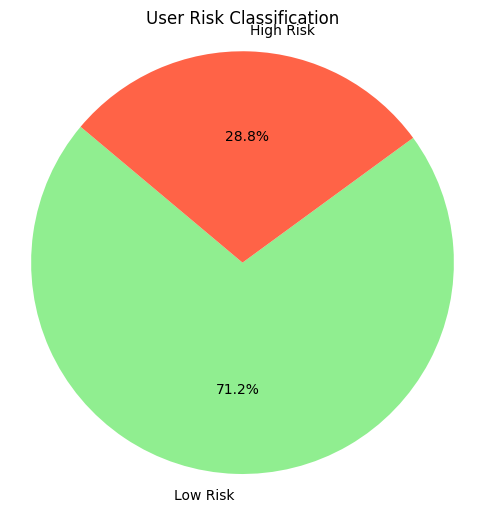

In [82]:
risk_counts = user_profile_df["HIGH_RISK_FLAG"].value_counts()
labels = ["Low Risk", "High Risk"]
colors = ["lightgreen", "tomato"]

plt.figure(figsize=(6, 6))
plt.pie(risk_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("User Risk Classification")
plt.axis('equal')
plt.show()